## Notebook 05: Tract Grocery Demand Classification

### Purpose

This notebook analyzes the spatial distribution of potential grocery demand across census tracts in Kootenai County.

Using the potential grocery demand indicator created in Notebook 03, census tracts are classified into different demand levels to identify areas with relatively higher or lower estimated grocery market potential.

### Output

A classified spatial dataset and choropleth map showing tract-level grocery demand patterns, with city labels added for geographic interpretation.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import geopandas as gpd 
import pandas as pd
from adjustText import adjust_text

In [2]:
project_root = Path.cwd()
if not Path('data').exists():
    project_root = project_root.parent
print(project_root)

d:\Wu\2026\Project Portfolio\003 Project\grocery-demand-estimation


### Load spatial data

In [3]:
demand_path = project_root / 'data/processed/potential_grocery_demand.gpkg'
city_path = project_root / 'data/processed/kootenai_cities.gpkg'

In [4]:
demand = gpd.read_file(demand_path, layer='tract_demand')
city = gpd.read_file(city_path, layer='cities')

### Grocery expenditure analysis at Tract level 

#### Inspect demand distribution

In [5]:
demand['potential_grocery_deman'].describe().map("{:,.0f}".format)

count            39
mean     11,169,097
std       4,648,388
min       3,324,258
25%       7,641,704
50%      10,703,059
75%      13,827,278
max      22,457,729
Name: potential_grocery_deman, dtype: str

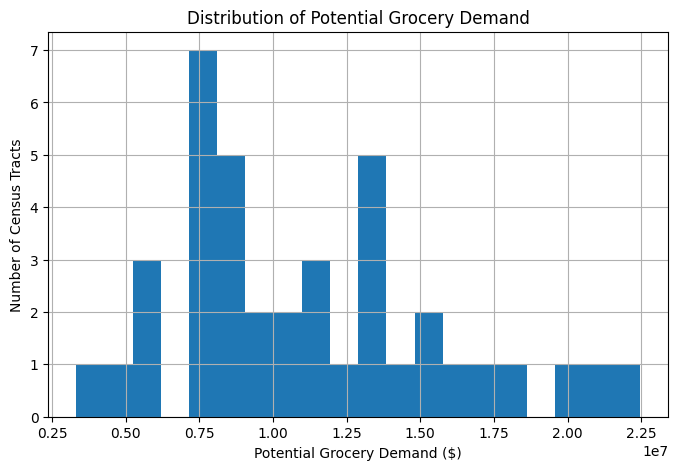

In [6]:
demand['potential_grocery_deman'].hist(
    bins=20, figsize=(8,5)
)
plt.xlabel('Potential Grocery Demand ($)')
plt.ylabel('Number of Census Tracts')
plt.title('Distribution of Potential Grocery Demand')
plt.show()

#### Classify the demand

In [7]:
demand.columns

Index(['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'NAMELSADCO', 'STATE_NAME', 'LSAD', 'ALAND',
       'AWATER', 'state', 'county', 'tract', 'household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery', 'potential_grocery_deman',
       'geometry'],
      dtype='str')

In [8]:
# create demand classes
# divide tracts into equal-width-demand groups  
labels = [
    "Low ($0–5M)",
    "Medium ($5M–10M)",
    "High ($10M–15M)",
    "Very High (>$15M)"
]

demand['demand_class'] = pd.cut(
    demand['potential_grocery_deman'],
    bins=4,
    labels = labels,
    include_lowest=True
) 

demand[['potential_grocery_deman', 'demand_class']].head()

,potential_grocery_deman,demand_class
0,5.874592e+06,Low ($0–5M)
1,8.448130e+06,Medium ($5M–10M)
2,1.084912e+07,Medium ($5M–10M)
3,1.992802e+07,Very High (>$15M)
4,1.549373e+07,High ($10M–15M)


In [9]:
demand['demand_class'].value_counts()

demand_class
Medium ($5M–10M)     13
Low ($0–5M)          12
High ($10M–15M)      10
Very High (>$15M)     4
Name: count, dtype: int64

#### Summarize demograhics by demand class

In [10]:
demo_list = ['household_count',
       'avg_household_size', 'median_income', 'median_age', 'owner_rate',
       'college_plus_pct', 'avg_grocery']

demand_summary = demand.groupby('demand_class')[demo_list].mean().round(0)
demand_summary

,household_count,avg_household_size,median_income,median_age,owner_rate,college_plus_pct,avg_grocery
demand_class,,,,,,,
Low ($0–5M),1115.0,2.0,81794.0,48.0,76.0,32.0,5872.0
Medium ($5M–10M),1624.0,3.0,82255.0,44.0,68.0,30.0,6193.0
High ($10M–15M),2342.0,3.0,87769.0,43.0,75.0,31.0,6354.0
Very High (>$15M),3315.0,3.0,86767.0,37.0,71.0,28.0,6162.0


In [16]:
demand_summary.to_csv(project_root/"outputs/tract_demand_profile.csv")

#### Correlation Analysis

In [11]:
corr_df = demand[demo_list + ['potential_grocery_deman']]

In [12]:
corr_matrix = corr_df.corr()
demand_corr = (
    corr_matrix['potential_grocery_deman']
    .drop('potential_grocery_deman')
    .sort_values(ascending=False)
)
demand_corr.round(2)
demand_corr

household_count       0.965562
avg_household_size    0.279909
avg_grocery           0.204559
median_income         0.118112
owner_rate           -0.042801
college_plus_pct     -0.135126
median_age           -0.461436
Name: potential_grocery_deman, dtype: float64

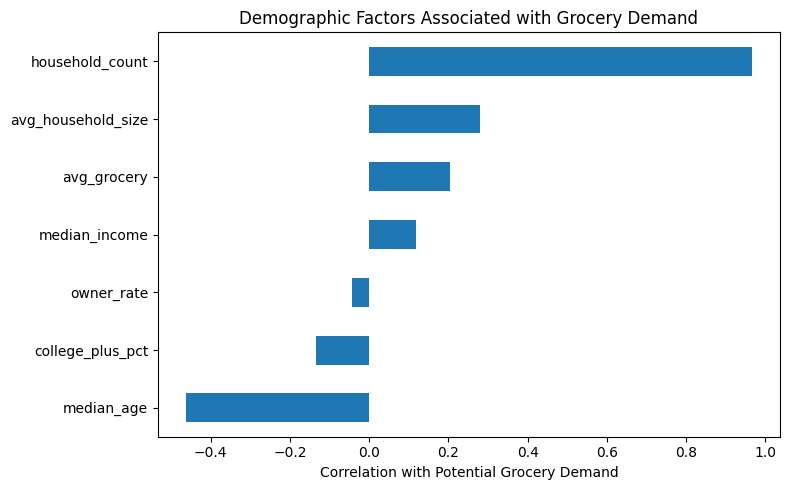

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

demand_corr.sort_values().plot(
    kind="barh",
    ax=ax
)

plt.xlabel("Correlation with Potential Grocery Demand")
plt.title("Demographic Factors Associated with Grocery Demand")

plt.tight_layout()

fig.savefig(
    project_root / "outputs/tract_grocery_expenditure_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Spatial Distribution Pattern of Grocery Demand

In [50]:
demand = demand.to_crs(epsg=26911)
city = city.to_crs(epsg=26911)


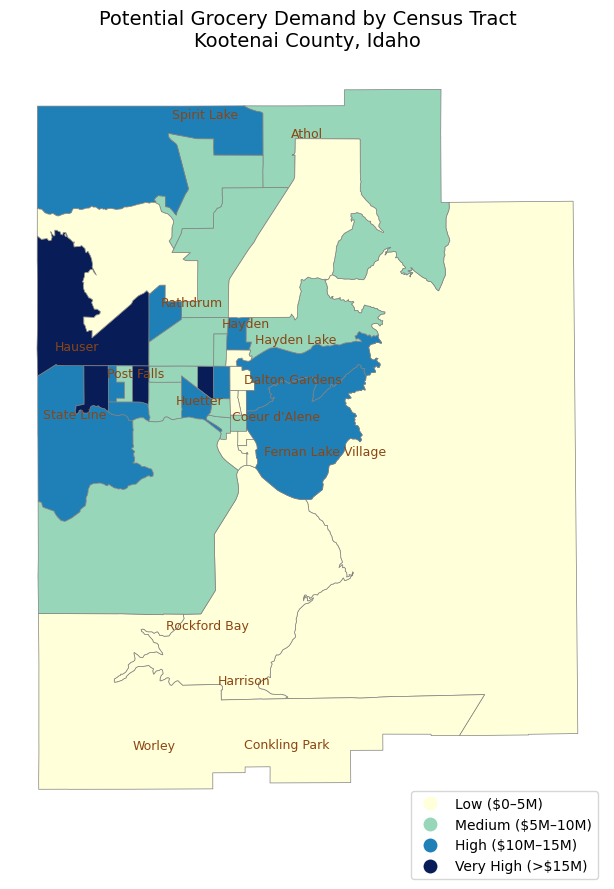

In [51]:
fig, ax = plt.subplots(figsize=(10,10))

demand.plot(
    column='demand_class',
    cmap="YlGnBu",
    linewidth=0.5,
    edgecolor="grey",
    legend=True,
    ax=ax
)

texts = []
for _, row in city.iterrows():
    label_point = row.geometry.representative_point()
    texts.append(
        ax.text(
            label_point.x,
            label_point.y,
            row["NAME"],
            color='saddlebrown',
            fontsize=9
        )
    )

adjust_text(texts)

ax.set_axis_off()
ax.set_title(
    "Potential Grocery Demand by Census Tract\nKootenai County, Idaho",
    fontsize=14
    )
legend = ax.get_legend()
legend.set_bbox_to_anchor((1, -0.08))
legend._loc = 4

fig.savefig(
    project_root / "outputs/potential_grocery_demand_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()